# Low Rank Nonnegative Matrix Factorization

## Problem

We want to solve

$$\min\limits_{U\in\mathbb{R}^{n\times m}, V\in\mathbb{R}^{m\times p}} \frac{1}{2}\|UV-X\|_2^2 + \iota_{\mathbb{R}_+^{n\times m}}(U) + \iota_{\mathbb{R}_+^{m\times n}}(V) + \iota_{\mathcal{C}}(U, V)$$

where $\mathcal{C}$ is some constraint set, i.e., the nuclear norm ball over the product space.

## Code

In [34]:
from jax import grad
import jax.numpy as jnp
import jax.random as random
from jax.scipy.linalg import svd
import matplotlib.pyplot as plt

In [35]:
# Generate a random matrix X
n, m, p = 100, 50, 80
key = random.PRNGKey(0)  # Random seed
X = random.normal(key, (n, p))

In [36]:
def lmo(gradient, radius, constraint_set):
    if constraint_set == "l1_ball":
        # Implement LMO for L1 ball
        # Handle both vector and matrix inputs
        index_flat = jnp.argmax(jnp.abs(gradient))
        index_multi = jnp.unravel_index(index_flat, gradient.shape)
        s = jnp.zeros_like(gradient)
        s = s.at[index_multi].set(jnp.sign(gradient[index_multi]))
        s = -radius * s
        return s

    elif constraint_set == "nuclear_norm_ball":
        # Implement LMO for nuclear norm ball
        # Assume gradient is a matrix
        u, s, vt = jnp.linalg.svd(gradient, full_matrices=False)
        u = u[:, :1]  # Take the first left singular vector
        vt = vt[:1, :]  # Take the first right singular vector
        s = -radius * jnp.outer(u[:, 0], vt[0, :])
        return s

    elif constraint_set == "l2_ball":
        # Implement LMO for L2 ball
        # Handle both vector and matrix inputs
        gradient_norm = jnp.linalg.norm(gradient)
        if gradient_norm > 0:
            s = -radius * gradient / gradient_norm
        else:
            # Handle the case when the gradient is zero
            s = jnp.zeros_like(gradient)
        return s
        
    else:
        raise ValueError(f"Unsupported constraint set: {constraint_set}")

In [37]:
# Define the projection onto the nonnegative orthant
def proj_nonneg(U):
    return jnp.maximum(U, 0)

def objective(U, V):
    return 0.5 * jnp.sum((U@V - X)**2)

auto_grad_U = grad(objective, argnums=0)
auto_grad_V = grad(objective, argnums=1)

def closed_grad_U(U, V):
    return jnp.dot(U@V - X, V.T)

def closed_grad_V(U, V):
    return jnp.dot(U.T, U@V - X)

In [38]:
def main_alg(U, V, U_rad, V_rad, n_steps):
    func_vals = jnp.zeros(n_steps)
    closed_func_vals = jnp.zeros(n_steps)
    gaps = jnp.zeros(n_steps)
    closed_gaps = jnp.zeros(n_steps)
    times = jnp.zeros(n_steps)

    for i in range(n_steps):
        U_grad = auto_grad_U(U, V)
        V_grad = auto_grad_V(U, V)
        closed_U_grad = closed_grad_U(U, V)
        closed_V_grad = closed_grad_V(U,V)

        U_direction = lmo(U_grad, U_rad, "nuclear_norm_ball")
        V_direction = lmo(V_grad, V_rad, "nuclear_norm_ball")
        closed_U_direction = lmo(closed_U_grad, U_rad, "nuclear_norm_ball")
        closed_V_direction = lmo(closed_V_grad, V_rad, "nuclear_norm_ball")

        step = 1.0 / (i + 1)

        U_new = (1 - step) * U + step * U_direction
        V_new = (1 - step) * V + step * V_direction
        closed_U_new = (1 - step) * U + step * closed_U_direction
        closed_V_new = (1 - step) * V + step * closed_V_direction

        func_val = objective(U_new, V_new)
        closed_func_val = objective(closed_U_new, closed_V_new)
        func_vals = func_vals.at[i].set(func_val)
        closed_func_vals = closed_func_vals.at[i].set(closed_func_val)

        U_gap = jnp.sum(U_grad * (U - U_direction))
        closed_U_gap = jnp.sum(closed_U_grad * (U - closed_U_direction))
        V_gap = jnp.sum(V_grad * (V - V_direction))
        closed_V_gap = jnp.sum(V_grad * (V - V_direction))
        gap = U_gap + V_gap
        closed_gap = closed_U_gap + closed_V_gap
        gaps = gaps.at[i].set(gap)
        closed_gaps = closed_gaps.at[i].set(closed_gap)

        U, V = U_new, V_new

    return U, V, func_vals, closed_func_vals, gaps, closed_gaps, times

In [39]:
# Set constraint set radii
U_rad = 10.0
V_rad = 10.0
U_init = random.normal(key, (n, m))
V_init = random.normal(key, (m, p))
n_steps = 100

In [40]:
U, V, func_vals, closed_func_vals, gaps, closed_gaps, _ = main_alg(U_init, V_init, U_rad, V_rad, n_steps)

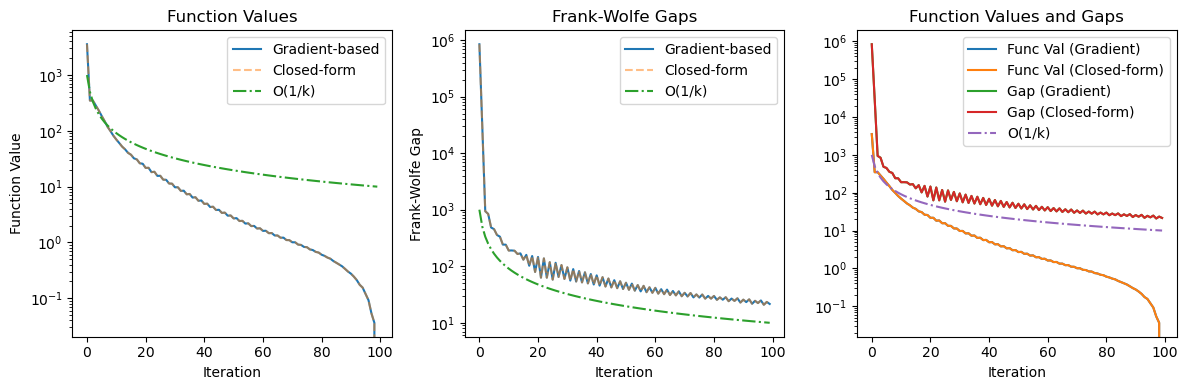

In [41]:
# Assuming you have the same data as before
num_iters = len(func_vals)
iters = jnp.arange(1, num_iters + 1)  # Iterations start from 1

# Compute O(1/k) values
one_over_k = 1e3 / iters

# Plot function values
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.semilogy(func_vals - func_vals[-1], label="Gradient-based")
plt.semilogy(closed_func_vals - closed_func_vals[-1], '--', alpha=0.5, label="Closed-form")
plt.semilogy(one_over_k, '-.', label="O(1/k)")  # Add O(1/k) line
plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Function Values")
plt.legend()

# Plot Frank-Wolfe gaps
plt.subplot(1, 3, 2)
plt.semilogy(gaps, label="Gradient-based")
plt.semilogy(closed_gaps, '--', alpha=0.5, label="Closed-form")
plt.semilogy(one_over_k, '-.', label="O(1/k)")  # Add O(1/k) line
plt.xlabel("Iteration")
plt.ylabel("Frank-Wolfe Gap")
plt.title("Frank-Wolfe Gaps")
plt.legend()

# Plot function values and gaps together
plt.subplot(1, 3, 3)
plt.semilogy(func_vals - func_vals[-1], label="Func Val (Gradient)")
plt.semilogy(closed_func_vals - closed_func_vals[-1], label="Func Val (Closed-form)")
plt.semilogy(gaps, label="Gap (Gradient)")
plt.semilogy(closed_gaps, label="Gap (Closed-form)")
plt.semilogy(one_over_k, '-.', label="O(1/k)")  # Add O(1/k) line
plt.xlabel("Iteration")
plt.title("Function Values and Gaps")
plt.legend()

plt.tight_layout()
plt.show()